# SIT307 – Task 6.2C: Classification Models

## Cirrhosis Patient Survival Prediction

This notebook presents the complete development and evaluation of machine learning classification models for predicting patient survival outcomes using the **Cirrhosis Patient Survival Prediction** dataset. The analysis follows a structured machine learning workflow, beginning with problem understanding and exploratory data analysis, followed by data preprocessing, model development, hyperparameter optimisation, class imbalance investigation and final model evaluation.

All modelling decisions are supported by quantitative analysis and interpreted in the context of the classification problem.

## Notebook Overview

The objective of this notebook is to develop classification models capable of predicting a patient's clinical outcome based on demographic information, treatment history and laboratory measurements collected from individuals diagnosed with cirrhosis.

The target variable for this task is **`Status`**, which contains three possible outcomes:

- **C** ~ The patient was alive at the end of the observation period.
- **D** ~ The patient died during the observation period.
- **CL** ~ The patient underwent a liver transplant.

As the target variable contains three distinct classes, this is a **multiclass classification** problem.

Two supervised machine learning algorithms will be developed and compared throughout this notebook:

1. Logistic Regression
2. Random Forest Classifier

The models will be evaluated using stratified cross-validation together with accuracy, macro precision, macro recall, macro F1-score and multiclass ROC-AUC. Particular attention will be given to the minority class so that model performance is assessed fairly rather than relying only on overall accuracy.

The notebook is organised into the following stages:

1. Understanding the classification problem.
2. Exploring and preparing the dataset.
3. Developing and optimising classification models.
4. Investigating the impact of class imbalance.
5. Evaluating the final model and comparing training strategies.
6. Reflecting on the overall modelling process.

### Required Libraries

The following libraries support data preparation, exploratory analysis, model development, hyperparameter optimisation, class-imbalance handling, evaluation and interpretation.

In [1]:
# General utilities
import warnings
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display notebook tables clearly
from IPython.display import display

# Data splitting, validation and hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

# Missing-value handling and feature transformation
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    label_binarize
)
from sklearn.compose import ColumnTransformer

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Class-imbalance handling
from imblearn.over_sampling import SMOTE

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model interpretation
from sklearn.inspection import permutation_importance

# Keep notebook outputs clean and readable
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

# Question 1: Understanding the Classification Problem

This section defines the classification task represented by the cirrhosis dataset. It identifies the input and output variables, explains the practical importance of predicting patient outcomes and considers the possible consequences of incorrect predictions.

The target variable is also examined to determine whether the task is binary or multiclass classification. The discussion is supported by evidence from the dataset, including the available clinical features and the distribution of the target classes.

### Load and Inspect the Dataset

The following code loads the cirrhosis dataset and displays its dimensions, first five rows and available variables.

In [2]:
# Suppress non-essential warnings
warnings.filterwarnings("ignore")

# Configure notebook display
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("cirrhosis.csv")

# Display the dataset structure
print("Dataset shape:", df.shape)
display(df.head())

print("Available variables:")
print(df.columns.tolist())

Dataset shape: (418, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5000,261.0000,2.6000,156.0000,1718.0000,137.9500,172.0000,190.0000,12.2000,4.0000
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1000,302.0000,4.1400,54.0000,7394.8000,113.5200,88.0000,221.0000,10.6000,3.0000
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4000,176.0000,3.4800,210.0000,516.0000,96.1000,55.0000,151.0000,12.0000,4.0000
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8000,244.0000,2.5400,64.0000,6121.8000,60.6300,92.0000,183.0000,10.3000,4.0000
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4000,279.0000,3.5300,143.0000,671.0000,113.1500,72.0000,136.0000,10.9000,3.0000


Available variables:
['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


### Examine the Classification Target

The following code summarises the classes in the `Status` target variable and calculates their counts and percentages.

In [3]:
# Calculate target class counts and percentages
target_summary = pd.DataFrame({
    "Count": df["Status"].value_counts(),
    "Percentage (%)": df["Status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
})

# Display the target distribution
display(target_summary)

,Count,Percentage (%)
Status,,
C,232,55.5000
D,161,38.5200
CL,25,5.9800


### Evaluation

This task aims to predict the clinical outcome of a patient diagnosed with cirrhosis using demographic, treatment-related and clinical information contained in the dataset.

The input variables include demographic features such as `Age` and `Sex`, treatment information such as `Drug`, clinical indicators including `Ascites`, `Hepatomegaly`, `Spiders` and `Edema`, and laboratory measurements such as `Bilirubin`, `Albumin`, `Copper`, `Platelets`, `Prothrombin` and `Stage`. The `ID` variable is only a patient identifier and will not be used for prediction. `N_Days` will also be excluded because it records the time between registration and the final observed outcome, which could introduce target leakage.

The output variable is `Status`, with three possible classes:

- `C` – the patient was alive at the end of follow-up.
- `D` – the patient died during follow-up.
- `CL` – the patient received a liver transplant.

The dataset contains 418 records. Class `C` contains 232 patients (55.50%), class `D` contains 161 patients (38.52%) and class `CL` contains 25 patients (5.98%). Therefore, this is a multiclass classification problem with a noticeable class imbalance.

The practical value of this task is to identify patterns associated with different patient outcomes. A reliable model could support clinical risk assessment and help identify patients who may require closer monitoring or further investigation. However, it should support rather than replace clinical judgement.

Classification errors may have different consequences. Predicting `C` for a patient whose actual outcome is `D` may underestimate their risk, while predicting `D` for a patient in class `C` may cause unnecessary concern or intervention. Misclassifying the small `CL` class may also reduce the model’s ability to recognise transplant-related outcomes.

Because the classes are imbalanced, accuracy alone may be misleading. Model evaluation should therefore also include macro-averaged precision, recall and F1-score, together with class-specific results, multiclass ROC-AUC and a confusion matrix.

# Question 2: Data Exploration and Preparation

This section examines the quality and structure of the cirrhosis dataset before model development. It assesses dataset dimensions, data types, missing values and target-class distribution.

The relationships between selected features and the target variable are then explored, followed by the preparation of the dataset for modelling. This includes removing unsuitable variables, separating the target, creating a 70:30 train-test split and defining the required preprocessing techniques.

### Data Quality Assessment

The following analysis examines the dataset dimensions, variable types, missing values, duplicate records and distribution of the target classes.

In [4]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Data types and missing values
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

display(quality_summary)

# Duplicate records
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Target class distribution
class_distribution = pd.DataFrame({
    "Count": df["Status"].value_counts(),
    "Percentage": (
        df["Status"].value_counts(normalize=True) * 100
    ).round(2)
})

print("Target class distribution:")
display(class_distribution)

# Identify feature types from the original dataset
continuous_features = [
    "Age", "Bilirubin", "Cholesterol", "Albumin", "Copper",
    "Alk_Phos", "SGOT", "Tryglicerides", "Platelets",
    "Prothrombin"
]

categorical_features = [
    "Drug", "Sex", "Ascites", "Hepatomegaly",
    "Spiders", "Edema"
]

ordinal_features = ["Stage"]

print("\nContinuous features:")
print(continuous_features)

print("\nCategorical features:")
print(categorical_features)

print("\nOrdinal feature:")
print(ordinal_features)

Rows: 418
Columns: 20


,Data Type,Missing Values,Missing Percentage,Unique Values
ID,int64,0,0.0000,418
N_Days,int64,0,0.0000,399
Status,object,0,0.0000,3
Drug,object,106,25.3600,2
Age,int64,0,0.0000,344
Sex,object,0,0.0000,2
Ascites,object,106,25.3600,2
Hepatomegaly,object,106,25.3600,2
Spiders,object,106,25.3600,2
Edema,object,0,0.0000,3



Duplicate rows: 0
Target class distribution:


,Count,Percentage
Status,,
C,232,55.5000
D,161,38.5200
CL,25,5.9800



Continuous features:
['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

Categorical features:
['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Ordinal feature:
['Stage']


### Exploratory Analysis

The following analysis compares selected clinical measurements across patient outcomes and examines correlations among numerical features to identify potentially informative or redundant variables.

Median numerical feature values by patient status:


,Bilirubin,Albumin,Copper,Prothrombin,Stage
Status,,,,,
C,0.9000,3.6000,52.0000,10.4000,3.0000
CL,3.1000,3.5300,102.0000,10.3000,3.0000
D,3.2000,3.4000,111.0000,11.0000,4.0000


Ascites distribution across patient status (%):


Status,C,CL,D
Ascites,,,
N,57.9900,6.6000,35.4200
Y,4.1700,0.0000,95.8300


Hepatomegaly distribution across patient status (%):


Status,C,CL,D
Hepatomegaly,,,
N,71.0500,4.6100,24.3400
Y,37.5000,7.5000,55.0000


Edema distribution across patient status (%):


Status,C,CL,D
Edema,,,
N,61.0200,6.2100,32.7700
S,34.0900,6.8200,59.0900
Y,5.0000,0.0000,95.0000


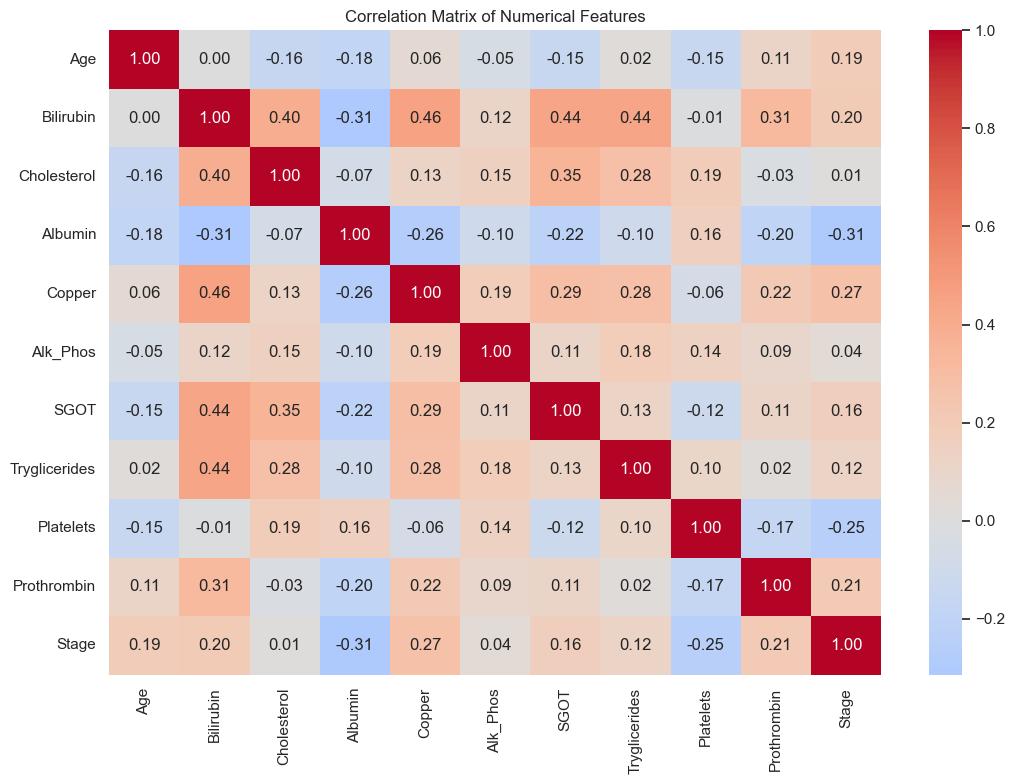

In [5]:
# Compare selected numerical features across patient outcomes
selected_features = [
    "Bilirubin",
    "Albumin",
    "Copper",
    "Prothrombin",
    "Stage"
]

status_summary = (
    df.groupby("Status")[selected_features]
    .median()
    .round(2)
)

print("Median numerical feature values by patient status:")
display(status_summary)

# Examine selected categorical features against the target
selected_categorical = [
    "Ascites",
    "Hepatomegaly",
    "Edema"
]

for feature in selected_categorical:
    relationship_table = (
        pd.crosstab(
            df[feature],
            df["Status"],
            normalize="index"
        )
        .mul(100)
        .round(2)
    )

    print(f"{feature} distribution across patient status (%):")
    display(relationship_table)

# Correlation analysis for numerical features
numeric_columns = (
    df.select_dtypes(include=np.number)
    .columns
    .drop(["ID", "N_Days"])
)

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Data Preparation: Feature Selection and Train-Test Split

The identifier and follow-up duration variables are removed because they are unsuitable predictors. Age is converted from days to years for clearer interpretation. The predictors and target are then separated, followed by a stratified 70:30 train-test split to preserve the original class distribution.

In [6]:
# Create a copy for model preparation
model_df = df.copy()

# Convert age from days to years
model_df["Age"] = model_df["Age"] / 365.25

# Remove unsuitable predictor variables
model_df = model_df.drop(columns=["ID", "N_Days"])

# Separate predictors and target
X = model_df.drop(columns=["Status"])
y = model_df["Status"]

# Create a stratified 70:30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f"Training features: {X_train.shape}")
print(f"Testing features: {X_test.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing labels: {y_test.shape}")

print("Training class distribution (%):")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

print("Testing class distribution (%):")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

Training features: (292, 17)
Testing features: (126, 17)
Training labels: (292,)
Testing labels: (126,)
Training class distribution (%):


,Percentage
Status,
C,55.4800
D,38.7000
CL,5.8200


Testing class distribution (%):


,Percentage
Status,
C,55.5600
D,38.1000
CL,6.3500


### Data Preparation: Preprocessing Pipeline

Numerical and categorical variables require different preprocessing methods. Missing numerical values are replaced using the median, while missing categorical values are replaced using the most frequent category. Numerical variables are standardised, and categorical variables are converted into numerical form using one-hot encoding. The preprocessing pipeline is fitted only on the training data to avoid data leakage.

In [7]:
# Define feature groups
numerical_features = [
    "Age",
    "Bilirubin",
    "Cholesterol",
    "Albumin",
    "Copper",
    "Alk_Phos",
    "SGOT",
    "Tryglicerides",
    "Platelets",
    "Prothrombin",
    "Stage"
]

categorical_features = [
    "Drug",
    "Sex",
    "Ascites",
    "Hepatomegaly",
    "Spiders",
    "Edema"
]

# Numerical preprocessing
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same fitted transformations to testing data
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed testing shape: {X_test_processed.shape}")
print("Preprocessing completed successfully.")

Processed training shape: (292, 24)
Processed testing shape: (126, 24)
Preprocessing completed successfully.


### Evaluation

The dataset contains 418 records and 20 original variables. No duplicate rows were identified, although several clinical and treatment-related features contained missing values. The target variable was imbalanced, with class C representing approximately 55.5% of observations, class D approximately 38.5%, and class CL only about 6%. This imbalance may make the minority CL class more difficult to predict accurately.

Exploratory analysis showed that clinical variables such as bilirubin, albumin, copper, prothrombin and disease stage differed across patient outcomes and may therefore provide useful predictive information. The correlation heatmap did not indicate severe numerical redundancy, so no additional features were removed on this basis.

The ID variable was excluded because it is only an identifier. N_Days was also removed because it directly represents survival duration and could introduce target leakage when predicting patient status. Age was converted from days to years to improve interpretability.

A stratified 70:30 split produced 292 training records and 126 testing records while preserving the original class proportions. Missing numerical values were replaced using the median because several clinical measurements were skewed and potentially affected by extreme values. Missing categorical values were replaced using the most frequent category. Numerical variables were standardised for Logistic Regression, while categorical variables were one-hot encoded.

After preprocessing, the 17 original predictors became 24 model-ready features. A limitation is that mode and median imputation may reduce natural variability, while the small number of CL cases may still limit model performance for that class.

## Question 3: Model Development and Selection

This section develops and compares Logistic Regression and Random Forest models for predicting patient survival status. Both models are evaluated using accuracy, precision, recall, F1-score and multiclass ROC-AUC. Cross-validation and hyperparameter optimisation are then used to identify the better-performing model.

### Model 1: Baseline Logistic Regression

Logistic Regression is used as an interpretable baseline model for the multiclass classification problem.

In [8]:
# Create the baseline Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model using the processed training data
logistic_model.fit(X_train_processed, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Baseline Logistic Regression Results

The baseline Logistic Regression model is evaluated on both the training and testing data using accuracy, macro precision, macro recall, macro F1-score and multiclass ROC-AUC. A confusion matrix is also used to visualise how well each survival class is classified.

Baseline Logistic Regression Results
Training Accuracy: 0.7740
Testing Accuracy: 0.6984
Testing Macro Precision: 0.4643
Testing Macro Recall: 0.4823
Testing Macro F1-score: 0.4702
Testing Macro ROC-AUC: 0.7771
Classification Report
              precision    recall  f1-score   support

           C       0.70      0.84      0.77        70
          CL       0.00      0.00      0.00         8
           D       0.69      0.60      0.64        48

    accuracy                           0.70       126
   macro avg       0.46      0.48      0.47       126
weighted avg       0.65      0.70      0.67       126



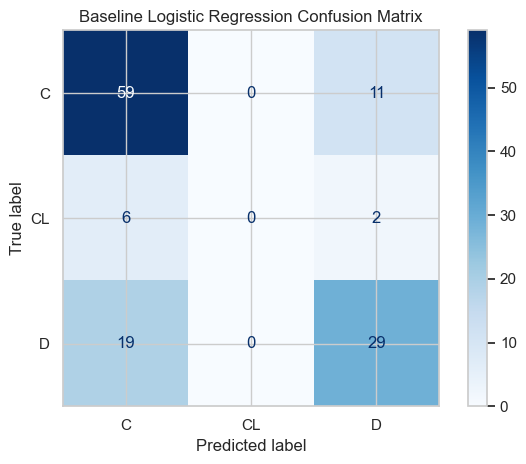

In [9]:
# Generate predictions for both the training and testing datasets
logistic_train_predictions = logistic_model.predict(X_train_processed)
logistic_test_predictions = logistic_model.predict(X_test_processed)

# Predict class probabilities for ROC-AUC calculation
logistic_test_probabilities = logistic_model.predict_proba(
    X_test_processed
)

# Store the evaluation metrics for easier comparison later
logistic_results = {
    "Training Accuracy": accuracy_score(
        y_train,
        logistic_train_predictions
    ),
    "Testing Accuracy": accuracy_score(
        y_test,
        logistic_test_predictions
    ),
    "Testing Macro Precision": precision_score(
        y_test,
        logistic_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro Recall": recall_score(
        y_test,
        logistic_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro F1-score": f1_score(
        y_test,
        logistic_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro ROC-AUC": roc_auc_score(
        y_test,
        logistic_test_probabilities,
        labels=logistic_model.classes_,
        multi_class="ovr",
        average="macro"
    )
}

print("Baseline Logistic Regression Results")

# Display each evaluation metric
for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")

print("Classification Report")
print(
    classification_report(
        y_test,
        logistic_test_predictions,
        zero_division=0
    )
)

# Build the confusion matrix using the actual predictions
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_test_predictions,
    labels=logistic_model.classes_
)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=logistic_model.classes_
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### Baseline Logistic Regression ROC Curve

The ROC curves illustrate the classification performance for each survival class using a one-vs-rest approach. The Area Under the Curve (AUC) summarises the model's ability to distinguish between classes, where larger values indicate better discrimination.

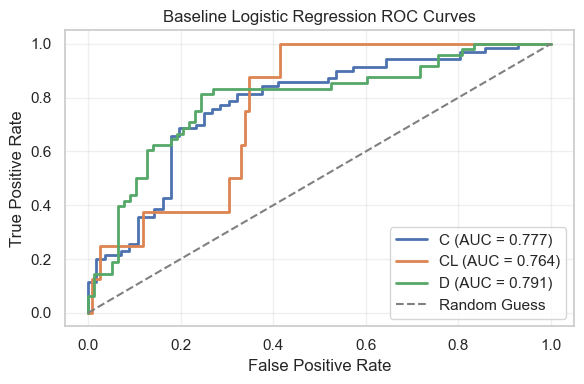

In [10]:
# Convert the multiclass labels into binary format for ROC analysis
y_test_binary = label_binarize(
    y_test,
    classes=logistic_model.classes_
)

plt.figure(figsize=(6, 4))

# Plot one ROC curve for each class
for class_index, class_name in enumerate(logistic_model.classes_):

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        logistic_test_probabilities[:, class_index]
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

# Plot the random guessing reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Logistic Regression ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Baseline Logistic Regression Evaluation

The baseline Logistic Regression model achieved a training accuracy of 77.40% and a testing accuracy of 69.84%. The moderate difference between these values suggests some overfitting, although the gap is not severe.

The model performed reasonably well for the two majority classes. Class C achieved a precision of 0.70, recall of 0.84 and F1-score of 0.77, showing that most censored patients were identified correctly. Class D also produced acceptable results, with a precision of 0.69, recall of 0.60 and F1-score of 0.64.

However, the model failed to correctly identify any patients in the minority CL class, resulting in precision, recall and F1-score values of 0.00. This poor minority-class performance reduced the macro precision, macro recall and macro F1-score to 0.4643, 0.4823 and 0.4702 respectively. This confirms that overall accuracy alone does not fully represent the model's performance on the imbalanced dataset.

The macro ROC-AUC score of 0.7771 indicates that the model has a reasonable overall ability to separate the three survival classes. The individual AUC values were 0.777 for C, 0.764 for CL and 0.791 for D. Although the CL ROC-AUC is acceptable, its classification results remain poor because the model does not assign CL as the final predicted class at the default decision threshold. Therefore, further optimisation and class-imbalance handling are required.

### Logistic Regression Hyperparameter Optimisation

The baseline model showed acceptable overall accuracy but failed to correctly classify the minority CL class. Hyperparameter optimisation is therefore applied using five-fold stratified cross-validation. Macro F1-score is used as the optimisation metric so that all three survival classes receive equal importance.

In [11]:
# Stratified cross-validation keeps the class proportions similar in each fold
logistic_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Test different regularisation strengths, penalties and solvers
logistic_parameter_grid = [
    {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"]
    },
    {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"]
    }
]

# Search for the combination that gives the best macro F1-score
logistic_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=logistic_parameter_grid,
    scoring="f1_macro",
    cv=logistic_cv,
    n_jobs=-1
)

# Fit the search only on the training data
logistic_grid_search.fit(
    X_train_processed,
    y_train
)

# Save the best-performing Logistic Regression model
tuned_logistic_model = logistic_grid_search.best_estimator_

print("Best Parameters:")
print(logistic_grid_search.best_params_)

print(
    "Best Cross-Validation Macro F1-score:",
    round(logistic_grid_search.best_score_, 4)
)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Macro F1-score: 0.5703


### Tuned Logistic Regression Results

The best Logistic Regression model used stronger regularisation with balanced class weights. It is now evaluated on the test data using the same metrics as the baseline model so that the effect of hyperparameter optimisation can be measured fairly.

Tuned Logistic Regression Results
Training Accuracy: 0.7158
Testing Accuracy: 0.6270
Testing Macro Precision: 0.5271
Testing Macro Recall: 0.5480
Testing Macro F1-score: 0.5170
Testing Macro ROC-AUC: 0.7718
Classification Report
              precision    recall  f1-score   support

           C       0.76      0.69      0.72        70
          CL       0.14      0.38      0.20         8
           D       0.68      0.58      0.63        48

    accuracy                           0.63       126
   macro avg       0.53      0.55      0.52       126
weighted avg       0.69      0.63      0.65       126



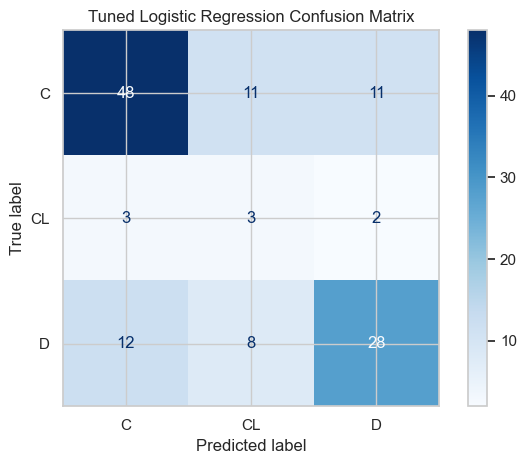

In [12]:
# Generate predictions using the tuned model
tuned_logistic_train_predictions = tuned_logistic_model.predict(
    X_train_processed
)

tuned_logistic_test_predictions = tuned_logistic_model.predict(
    X_test_processed
)

# Predict class probabilities for ROC-AUC analysis
tuned_logistic_test_probabilities = tuned_logistic_model.predict_proba(
    X_test_processed
)

# Calculate the same evaluation metrics used for the baseline model
tuned_logistic_results = {
    "Training Accuracy": accuracy_score(
        y_train,
        tuned_logistic_train_predictions
    ),
    "Testing Accuracy": accuracy_score(
        y_test,
        tuned_logistic_test_predictions
    ),
    "Testing Macro Precision": precision_score(
        y_test,
        tuned_logistic_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro Recall": recall_score(
        y_test,
        tuned_logistic_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro F1-score": f1_score(
        y_test,
        tuned_logistic_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro ROC-AUC": roc_auc_score(
        y_test,
        tuned_logistic_test_probabilities,
        labels=tuned_logistic_model.classes_,
        multi_class="ovr",
        average="macro"
    )
}

print("Tuned Logistic Regression Results")

for metric, value in tuned_logistic_results.items():
    print(f"{metric}: {value:.4f}")

print("Classification Report")
print(
    classification_report(
        y_test,
        tuned_logistic_test_predictions,
        zero_division=0
    )
)

# Create the confusion matrix from the actual test predictions
tuned_logistic_confusion_matrix = confusion_matrix(
    y_test,
    tuned_logistic_test_predictions,
    labels=tuned_logistic_model.classes_
)

ConfusionMatrixDisplay(
    confusion_matrix=tuned_logistic_confusion_matrix,
    display_labels=tuned_logistic_model.classes_
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### Tuned Logistic Regression ROC Curves

The ROC curves show how well the tuned model separates each class using a one-vs-rest approach. The class-specific AUC values are also reported to support comparison with the baseline model.

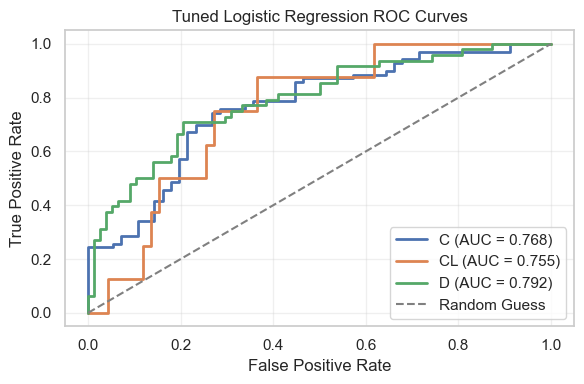

In [13]:
# Convert the target labels into binary form for multiclass ROC analysis
y_test_binary = label_binarize(
    y_test,
    classes=tuned_logistic_model.classes_
)

plt.figure(figsize=(6, 4))

# Plot one ROC curve for each survival class
for class_index, class_name in enumerate(tuned_logistic_model.classes_):

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        tuned_logistic_test_probabilities[:, class_index]
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

# Add the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Logistic Regression ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Baseline and Tuned Logistic Regression Comparison

The baseline and tuned Logistic Regression models are compared using test accuracy, macro precision, macro recall, macro F1-score and macro ROC-AUC.

In [14]:
logistic_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        logistic_results["Testing Accuracy"],
        tuned_logistic_results["Testing Accuracy"]
    ],
    "Macro Precision": [
        logistic_results["Testing Macro Precision"],
        tuned_logistic_results["Testing Macro Precision"]
    ],
    "Macro Recall": [
        logistic_results["Testing Macro Recall"],
        tuned_logistic_results["Testing Macro Recall"]
    ],
    "Macro F1-score": [
        logistic_results["Testing Macro F1-score"],
        tuned_logistic_results["Testing Macro F1-score"]
    ],
    "Macro ROC-AUC": [
        logistic_results["Testing Macro ROC-AUC"],
        tuned_logistic_results["Testing Macro ROC-AUC"]
    ]
})

display(logistic_comparison.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro ROC-AUC
0,Baseline Logistic Regression,0.6984,0.4643,0.4823,0.4702,0.7771
1,Tuned Logistic Regression,0.6270,0.5271,0.5480,0.5170,0.7718


### Tuned Logistic Regression Evaluation

Hyperparameter optimisation changed the behaviour of the Logistic Regression model. The tuned model used stronger regularisation (C = 0.01) together with balanced class weights, which encouraged the classifier to place greater emphasis on the minority CL class.

Although the testing accuracy decreased from 69.84% to 62.70%, the macro precision, macro recall and macro F1-score all improved from 0.4643, 0.4823 and 0.4702 to 0.5271, 0.5480 and 0.5170 respectively. These improvements indicate that the tuned model achieved a better balance across all three classes rather than favouring the majority classes.

The baseline model failed to correctly classify any CL samples, producing precision, recall and F1-score values of 0.00 for this class. After tuning, the model successfully identified several CL cases, increasing the CL recall to 0.38 and the F1-score to 0.20. This demonstrates that balanced class weighting reduced the bias towards the majority classes.

The macro ROC-AUC remained almost unchanged (0.7771 vs 0.7718), indicating that the overall class separability was similar before and after tuning. However, the tuned model achieved a more balanced classification performance, which is more appropriate for this imbalanced multiclass dataset. Consequently, the tuned Logistic Regression model is selected as the preferred version despite its lower overall accuracy.

### Model 2: Baseline Random Forest

Random Forest is used as the second classification model because it can capture nonlinear relationships and interactions between the clinical features without assuming a linear decision boundary.

In [15]:
# Create a baseline Random Forest using the default model settings
random_forest_model = RandomForestClassifier(
    random_state=42
)

# Train the model using the processed training data
random_forest_model.fit(
    X_train_processed,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Baseline Random Forest Results

The baseline Random Forest model is evaluated using the same metrics as Logistic Regression to ensure a fair comparison. Its performance is measured using accuracy, macro precision, macro recall, macro F1-score and multiclass ROC-AUC.

Baseline Random Forest Results
Training Accuracy: 1.0000
Testing Accuracy: 0.7302
Testing Macro Precision: 0.4841
Testing Macro Recall: 0.5036
Testing Macro F1-score: 0.4906
Testing Macro ROC-AUC: 0.7361
Classification Report
              precision    recall  f1-score   support

           C       0.74      0.89      0.81        70
          CL       0.00      0.00      0.00         8
           D       0.71      0.62      0.67        48

    accuracy                           0.73       126
   macro avg       0.48      0.50      0.49       126
weighted avg       0.68      0.73      0.70       126



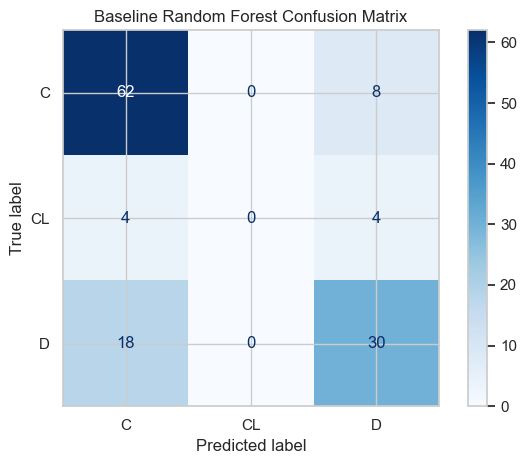

In [16]:
# Generate predictions for the training and testing datasets
random_forest_train_predictions = random_forest_model.predict(
    X_train_processed
)

random_forest_test_predictions = random_forest_model.predict(
    X_test_processed
)

# Predict class probabilities for the ROC-AUC calculation
random_forest_test_probabilities = random_forest_model.predict_proba(
    X_test_processed
)

# Store all main evaluation results in one dictionary
random_forest_results = {
    "Training Accuracy": accuracy_score(
        y_train,
        random_forest_train_predictions
    ),
    "Testing Accuracy": accuracy_score(
        y_test,
        random_forest_test_predictions
    ),
    "Testing Macro Precision": precision_score(
        y_test,
        random_forest_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro Recall": recall_score(
        y_test,
        random_forest_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro F1-score": f1_score(
        y_test,
        random_forest_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro ROC-AUC": roc_auc_score(
        y_test,
        random_forest_test_probabilities,
        labels=random_forest_model.classes_,
        multi_class="ovr",
        average="macro"
    )
}

print("Baseline Random Forest Results")

# Print the main evaluation metrics
for metric, value in random_forest_results.items():
    print(f"{metric}: {value:.4f}")

print("Classification Report")
print(
    classification_report(
        y_test,
        random_forest_test_predictions,
        zero_division=0
    )
)

# Create the confusion matrix using the actual test predictions
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_test_predictions,
    labels=random_forest_model.classes_
)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=random_forest_confusion_matrix,
    display_labels=random_forest_model.classes_
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Baseline Random Forest ROC Curves

The ROC curves show how effectively the Random Forest model distinguishes each survival class using a one-vs-rest approach.

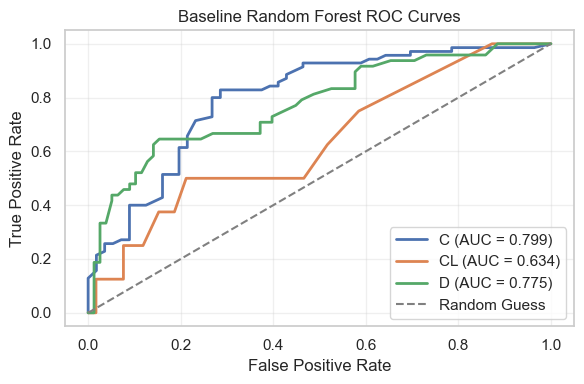

In [17]:
# Convert the multiclass target into binary columns for ROC analysis
y_test_binary = label_binarize(
    y_test,
    classes=random_forest_model.classes_
)

plt.figure(figsize=(6, 4))

# Plot one ROC curve for each survival class
for class_index, class_name in enumerate(random_forest_model.classes_):

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        random_forest_test_probabilities[:, class_index]
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

# Add the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Random Forest ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show() 

### Baseline Random Forest Evaluation

The baseline Random Forest achieved the highest testing accuracy among the untuned models at 73.02%. However, its training accuracy was 100%, which indicates that the model strongly overfitted the training data.

The macro F1-score was 0.4906 and the macro ROC-AUC was 0.7361. The model performed well for the majority classes, correctly identifying most C and D cases. However, it failed to correctly classify any CL cases, resulting in zero precision, recall and F1-score for the minority class.

Therefore, although the baseline Random Forest produced strong overall accuracy, its performance was not balanced across all three classes. This shows that accuracy alone is not sufficient for evaluating the model because the dataset is highly imbalanced.

 ### Random Forest Hyperparameter Optimisation

The baseline Random Forest achieved the highest overall accuracy but showed clear signs of overfitting and failed to correctly classify the minority CL class. Hyperparameter optimisation is therefore performed using five-fold stratified cross-validation with macro F1-score as the optimisation metric.

In [18]:
# Candidate hyperparameters for Random Forest
random_forest_parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

# Perform grid search using five-fold stratified cross-validation
random_forest_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=random_forest_parameter_grid,
    scoring="f1_macro",
    cv=logistic_cv,
    n_jobs=-1
)

# Train all candidate models
random_forest_grid_search.fit(
    X_train_processed,
    y_train
)

# Store the best-performing model
tuned_random_forest_model = (
    random_forest_grid_search.best_estimator_
)

print("Best Parameters:")
print(random_forest_grid_search.best_params_)

print(
    "Best Cross-Validation Macro F1-score:",
    round(random_forest_grid_search.best_score_, 4)
)

Best Parameters:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Macro F1-score: 0.6797


### Tuned Random Forest Results

The best Random Forest configuration uses balanced class weights and additional restrictions on leaf and split sizes. The tuned model is now evaluated on the test set using the same metrics as the baseline model.

Tuned Random Forest Results

Training Accuracy: 0.9110
Testing Accuracy: 0.6905
Testing Macro Precision: 0.5331
Testing Macro Recall: 0.5145
Testing Macro F1-score: 0.5199
Testing Macro ROC-AUC: 0.7161
Classification Report
              precision    recall  f1-score   support

           C       0.74      0.81      0.78        70
          CL       0.20      0.12      0.15         8
           D       0.66      0.60      0.63        48

    accuracy                           0.69       126
   macro avg       0.53      0.51      0.52       126
weighted avg       0.68      0.69      0.68       126



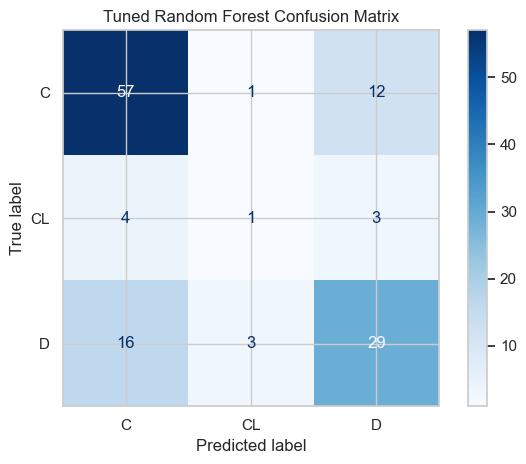

In [19]:
# Generate predictions for the training and testing datasets
tuned_random_forest_train_predictions = (
    tuned_random_forest_model.predict(X_train_processed)
)

tuned_random_forest_test_predictions = (
    tuned_random_forest_model.predict(X_test_processed)
)

# Obtain class probabilities for the ROC-AUC calculation
tuned_random_forest_test_probabilities = (
    tuned_random_forest_model.predict_proba(X_test_processed)
)

# Calculate the same metrics used for the baseline models
tuned_random_forest_results = {
    "Training Accuracy": accuracy_score(
        y_train,
        tuned_random_forest_train_predictions
    ),
    "Testing Accuracy": accuracy_score(
        y_test,
        tuned_random_forest_test_predictions
    ),
    "Testing Macro Precision": precision_score(
        y_test,
        tuned_random_forest_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro Recall": recall_score(
        y_test,
        tuned_random_forest_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro F1-score": f1_score(
        y_test,
        tuned_random_forest_test_predictions,
        average="macro",
        zero_division=0
    ),
    "Testing Macro ROC-AUC": roc_auc_score(
        y_test,
        tuned_random_forest_test_probabilities,
        labels=tuned_random_forest_model.classes_,
        multi_class="ovr",
        average="macro"
    )
}

print("Tuned Random Forest Results\n")

# Display the main evaluation scores
for metric, value in tuned_random_forest_results.items():
    print(f"{metric}: {value:.4f}")

print("Classification Report")
print(
    classification_report(
        y_test,
        tuned_random_forest_test_predictions,
        zero_division=0
    )
)

# Build the confusion matrix from the actual test predictions
tuned_random_forest_confusion_matrix = confusion_matrix(
    y_test,
    tuned_random_forest_test_predictions,
    labels=tuned_random_forest_model.classes_
)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=tuned_random_forest_confusion_matrix,
    display_labels=tuned_random_forest_model.classes_
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Tuned Random Forest ROC Curves

The ROC curves evaluate how effectively the tuned Random Forest separates each survival class using a one-vs-rest approach.

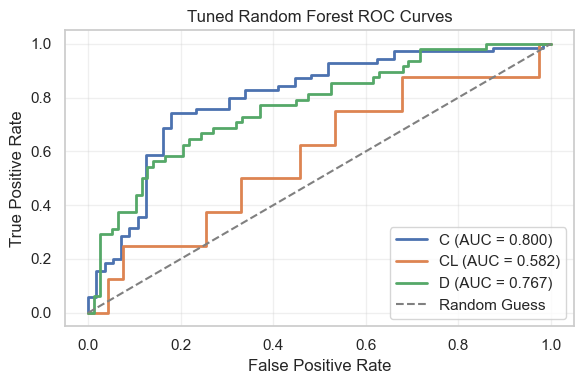

In [20]:
# Convert the target labels into binary columns for multiclass ROC analysis
y_test_binary = label_binarize(
    y_test,
    classes=tuned_random_forest_model.classes_
)

plt.figure(figsize=(6, 4))

# Calculate and plot one ROC curve for each class
for class_index, class_name in enumerate(
    tuned_random_forest_model.classes_
):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        tuned_random_forest_test_probabilities[:, class_index]
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

# Add the diagonal reference representing random classification
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Baseline and Tuned Random Forest Comparison

The baseline and tuned Random Forest models are compared using accuracy, macro precision, macro recall, macro F1-score and macro ROC-AUC.

In [21]:
random_forest_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        random_forest_results["Testing Accuracy"],
        tuned_random_forest_results["Testing Accuracy"]
    ],
    "Macro Precision": [
        random_forest_results["Testing Macro Precision"],
        tuned_random_forest_results["Testing Macro Precision"]
    ],
    "Macro Recall": [
        random_forest_results["Testing Macro Recall"],
        tuned_random_forest_results["Testing Macro Recall"]
    ],
    "Macro F1-score": [
        random_forest_results["Testing Macro F1-score"],
        tuned_random_forest_results["Testing Macro F1-score"]
    ],
    "Macro ROC-AUC": [
        random_forest_results["Testing Macro ROC-AUC"],
        tuned_random_forest_results["Testing Macro ROC-AUC"]
    ]
})

display(random_forest_comparison.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro ROC-AUC
0,Baseline Random Forest,0.7302,0.4841,0.5036,0.4906,0.7361
1,Tuned Random Forest,0.6905,0.5331,0.5145,0.5199,0.7161


### Random Forest Model Comparison

Hyperparameter optimisation reduced the Random Forest model's overfitting and slightly improved its balance across the three classes. The baseline model achieved 100% training accuracy but only 73.02% testing accuracy, indicating that it had memorised the training data. After tuning, training accuracy decreased to 91.10%, while testing accuracy decreased to 69.05%, producing a smaller generalisation gap.

The tuned model improved macro precision from 0.4841 to 0.5331 and macro F1-score from 0.4906 to 0.5199. However, macro recall increased only slightly from 0.5036 to 0.5145. The tuned model also correctly identified 1 of the 8 CL cases, whereas the baseline model identified none. This shows that balanced class weights encouraged the model to consider the minority class, although CL performance remained weak.

The macro ROC-AUC decreased from 0.7361 to 0.7161. The class-specific AUC for CL also decreased from 0.634 to 0.582, showing that tuning did not improve the model's probability-based separation of the minority class. Overall, tuning reduced overfitting and produced slightly better macro-averaged classification results, but the improvement in minority-class detection was limited.

### Final Model Comparison

The baseline and tuned versions of Logistic Regression and Random Forest are compared using the same test-set evaluation metrics.

In [22]:
# Combine the results from all four models into one comparison table
final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_results["Testing Accuracy"],
        tuned_logistic_results["Testing Accuracy"],
        random_forest_results["Testing Accuracy"],
        tuned_random_forest_results["Testing Accuracy"]
    ],
    "Macro Precision": [
        logistic_results["Testing Macro Precision"],
        tuned_logistic_results["Testing Macro Precision"],
        random_forest_results["Testing Macro Precision"],
        tuned_random_forest_results["Testing Macro Precision"]
    ],
    "Macro Recall": [
        logistic_results["Testing Macro Recall"],
        tuned_logistic_results["Testing Macro Recall"],
        random_forest_results["Testing Macro Recall"],
        tuned_random_forest_results["Testing Macro Recall"]
    ],
    "Macro F1-score": [
        logistic_results["Testing Macro F1-score"],
        tuned_logistic_results["Testing Macro F1-score"],
        random_forest_results["Testing Macro F1-score"],
        tuned_random_forest_results["Testing Macro F1-score"]
    ],
    "Macro ROC-AUC": [
        logistic_results["Testing Macro ROC-AUC"],
        tuned_logistic_results["Testing Macro ROC-AUC"],
        random_forest_results["Testing Macro ROC-AUC"],
        tuned_random_forest_results["Testing Macro ROC-AUC"]
    ]
})

display(final_model_comparison.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro ROC-AUC
0,Baseline Logistic Regression,0.6984,0.4643,0.4823,0.4702,0.7771
1,Tuned Logistic Regression,0.6270,0.5271,0.5480,0.5170,0.7718
2,Baseline Random Forest,0.7302,0.4841,0.5036,0.4906,0.7361
3,Tuned Random Forest,0.6905,0.5331,0.5145,0.5199,0.7161


 ### Final Model Selection

The four models showed different strengths. The baseline Random Forest achieved the highest overall accuracy at 73.02%, but it also showed clear overfitting with 100% training accuracy and failed to correctly classify any CL cases.

The tuned Random Forest produced the highest macro F1-score at 0.5199 and the highest macro precision at 0.5331. However, its macro recall was lower than the tuned Logistic Regression, and it correctly identified only 1 of the 8 CL cases.

The tuned Logistic Regression achieved the highest macro recall at 0.5480 and correctly classified 3 of the 8 CL cases. It also maintained a strong macro ROC-AUC of 0.7718, which was higher than both Random Forest models. Although its overall accuracy was lower at 62.70%, it provided the most balanced performance across the three survival classes.

Therefore, the tuned Logistic Regression is selected as the preferred model. This choice prioritises balanced class performance and minority-class detection over overall accuracy, which is more appropriate for this imbalanced clinical classification problem.

## Question 4: Addressing Data Imbalance

This section investigates the target-class distribution and evaluates whether applying SMOTE improves the performance of the tuned Logistic Regression and tuned Random Forest models.

,Count,Percentage (%)
Status,,
C,162,55.4795
D,113,38.6986
CL,17,5.8219


Majority-to-minority imbalance ratio: 9.53:1


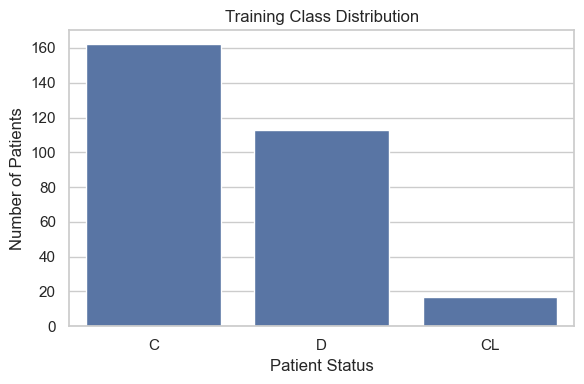

In [23]:
# Investigate the class distribution in the training data
class_counts = y_train.value_counts()
class_percentages = y_train.value_counts(normalize=True).mul(100)
imbalance_ratio = class_counts.max() / class_counts.min()

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

display(class_distribution)

print(f"Majority-to-minority imbalance ratio: {imbalance_ratio:.2f}:1")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, order=class_counts.index)

plt.title("Training Class Distribution")
plt.xlabel("Patient Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Class Imbalance and Selected Technique

The training dataset contains substantial class imbalance. Class C represents 55.48% of the training observations, while the minority class CL represents only 5.82%. The majority class therefore contains approximately 9.53 times more observations than the minority class.

This imbalance can cause the models to prioritise the majority classes while learning insufficient patterns for CL. This behaviour was observed in Question 3, where minority-class predictions remained considerably weaker than predictions for C and D.

SMOTE is applied to address this problem by generating synthetic training examples for the underrepresented classes. Unlike simply duplicating existing observations, SMOTE creates new samples between neighbouring minority-class observations. It is applied only to the training data so that the testing data remains unchanged and provides an unbiased evaluation.

In [24]:
# Apply SMOTE only to the processed training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

# Compare class distributions before and after SMOTE
before_smote = y_train.value_counts().sort_index()
after_smote = pd.Series(y_train_smote).value_counts().sort_index()

smote_distribution = pd.DataFrame({
    "Before SMOTE": before_smote,
    "After SMOTE": after_smote
})

display(smote_distribution)

# Train Logistic Regression using the tuned Q3 settings
smote_logistic = LogisticRegression(
    C=0.01,
    class_weight="balanced",
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

smote_logistic.fit(X_train_smote, y_train_smote)

# Train Random Forest using the tuned Q3 settings
smote_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=4,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

smote_random_forest.fit(X_train_smote, y_train_smote)

,Before SMOTE,After SMOTE
Status,,
C,162,162
CL,17,162
D,113,162


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Performance Comparison After SMOTE

The tuned models are evaluated after applying SMOTE and compared with their original results to assess whether class balancing improved performance.

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC,CL Recall
0,Tuned Logistic,0.6270,0.5271,0.5480,0.5170,0.7718,0.3750
1,Tuned Logistic + SMOTE,0.6190,0.5197,0.5454,0.5137,0.7789,0.3750
2,Tuned Random Forest,0.6905,0.5331,0.5145,0.5199,0.7161,0.1250
3,Tuned Random Forest + SMOTE,0.6825,0.4733,0.4706,0.4704,0.7081,0.0000


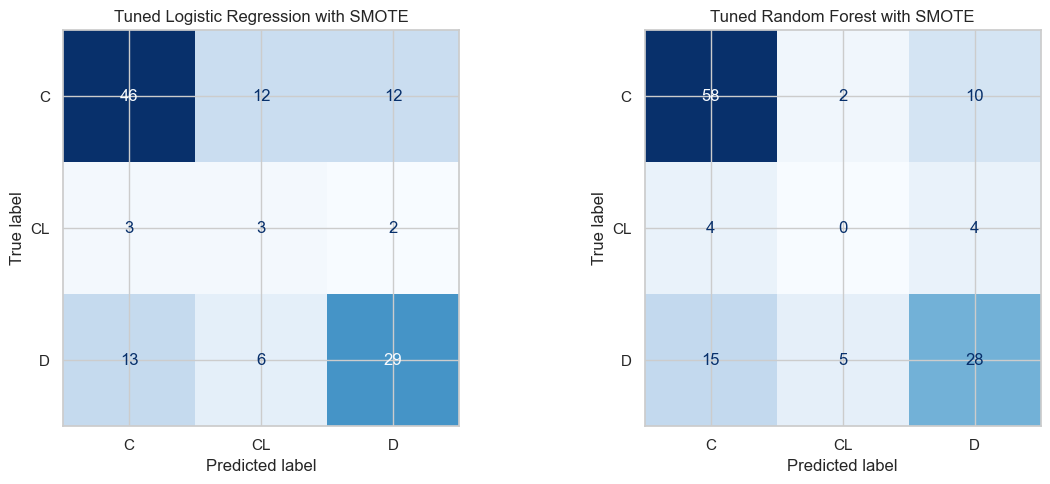

In [25]:
# Predictions from the tuned Logistic Regression with SMOTE
logistic_smote_pred = smote_logistic.predict(X_test_processed)
logistic_smote_prob = smote_logistic.predict_proba(X_test_processed)

# Predictions from the tuned Random Forest with SMOTE
rf_smote_pred = smote_random_forest.predict(X_test_processed)
rf_smote_prob = smote_random_forest.predict_proba(X_test_processed)


# Logistic Regression results after SMOTE
logistic_smote_accuracy = accuracy_score(y_test, logistic_smote_pred)
logistic_smote_precision = precision_score(
    y_test, logistic_smote_pred, average="macro", zero_division=0
)
logistic_smote_recall = recall_score(
    y_test, logistic_smote_pred, average="macro", zero_division=0
)
logistic_smote_f1 = f1_score(
    y_test, logistic_smote_pred, average="macro", zero_division=0
)
logistic_smote_auc = roc_auc_score(
    y_test,
    logistic_smote_prob,
    multi_class="ovr",
    average="macro",
    labels=smote_logistic.classes_
)

logistic_report = classification_report(
    y_test,
    logistic_smote_pred,
    output_dict=True,
    zero_division=0
)

logistic_cl_recall = logistic_report["CL"]["recall"]


# Random Forest results after SMOTE
rf_smote_accuracy = accuracy_score(y_test, rf_smote_pred)
rf_smote_precision = precision_score(
    y_test, rf_smote_pred, average="macro", zero_division=0
)
rf_smote_recall = recall_score(
    y_test, rf_smote_pred, average="macro", zero_division=0
)
rf_smote_f1 = f1_score(
    y_test, rf_smote_pred, average="macro", zero_division=0
)
rf_smote_auc = roc_auc_score(
    y_test,
    rf_smote_prob,
    multi_class="ovr",
    average="macro",
    labels=smote_random_forest.classes_
)

rf_report = classification_report(
    y_test,
    rf_smote_pred,
    output_dict=True,
    zero_division=0
)

rf_cl_recall = rf_report["CL"]["recall"]


# Compare results before and after SMOTE
comparison_results = pd.DataFrame({
    "Model": [
        "Tuned Logistic",
        "Tuned Logistic + SMOTE",
        "Tuned Random Forest",
        "Tuned Random Forest + SMOTE"
    ],
    "Accuracy": [
        0.6270,
        logistic_smote_accuracy,
        0.6905,
        rf_smote_accuracy
    ],
    "Macro Precision": [
        0.5271,
        logistic_smote_precision,
        0.5331,
        rf_smote_precision
    ],
    "Macro Recall": [
        0.5480,
        logistic_smote_recall,
        0.5145,
        rf_smote_recall
    ],
    "Macro F1": [
        0.5170,
        logistic_smote_f1,
        0.5199,
        rf_smote_f1
    ],
    "Macro ROC-AUC": [
        0.7718,
        logistic_smote_auc,
        0.7161,
        rf_smote_auc
    ],
    "CL Recall": [
        3 / 8,
        logistic_cl_recall,
        1 / 8,
        rf_cl_recall
    ]
})

display(comparison_results.round(4))


# Display both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_smote_pred,
    display_labels=["C", "CL", "D"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title("Tuned Logistic Regression with SMOTE")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_smote_pred,
    display_labels=["C", "CL", "D"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1]
)

axes[1].set_title("Tuned Random Forest with SMOTE")

plt.tight_layout()
plt.show()

### Effect of SMOTE on Model Performance

SMOTE did not improve the overall performance of either tuned model.

For logistic regression, the macro ROC-AUC increased slightly from 0.7718 to 0.7789. However, accuracy, macro precision, macro recall and macro F1-score all decreased slightly. The model still correctly identified 3 of the 8 CL cases, meaning minority-class recall remained unchanged at 0.3750.

For Random Forest, performance declined across all metrics after SMOTE. Most importantly, the model failed to correctly identify any CL cases, reducing CL recall from 0.1250 to 0.0000.

Overall, SMOTE did not provide a meaningful improvement. The tuned Logistic Regression without SMOTE remains the preferred model because it achieved better balanced performance while maintaining the same minority-class recall.

## Question 5: Final Model Evaluation and Recommendation

This section evaluates the final classification models based on the results obtained in the previous questions. The tuned Logistic Regression and tuned Random Forest models are compared using the original 70:30 train-test split and are then re-evaluated using an 80:20 split to assess their robustness, generalisation and suitability for deployment.

### Error Analysis Using the 70:30 Split

The existing predictions from the tuned Logistic Regression and tuned Random Forest models are used to examine their classification errors. The classification reports show the performance of each model for the individual target classes, while the confusion matrices provide a direct comparison between the actual and predicted outcomes.

Tuned Logistic Regression Classification Report
              precision    recall  f1-score   support

           C       0.76      0.69      0.72        70
          CL       0.14      0.38      0.20         8
           D       0.68      0.58      0.63        48

    accuracy                           0.63       126
   macro avg       0.53      0.55      0.52       126
weighted avg       0.69      0.63      0.65       126

Tuned Random Forest Classification Report
              precision    recall  f1-score   support

           C       0.74      0.81      0.78        70
          CL       0.20      0.12      0.15         8
           D       0.66      0.60      0.63        48

    accuracy                           0.69       126
   macro avg       0.53      0.51      0.52       126
weighted avg       0.68      0.69      0.68       126



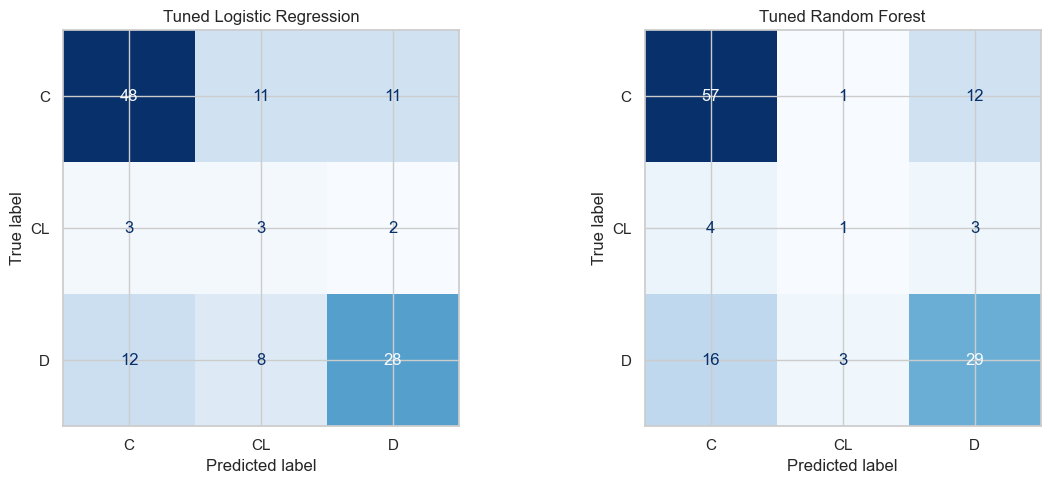

In [26]:
# Classification reports for the tuned models using the 70:30 split

print("Tuned Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        tuned_logistic_test_predictions,
        zero_division=0
    )
)


print("Tuned Random Forest Classification Report")
print(
    classification_report(
        y_test,
        tuned_random_forest_test_predictions,
        zero_division=0
    )
)


# Display confusion matrices 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_logistic_test_predictions,
    display_labels=tuned_logistic_model.classes_,
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=axes[0]
)
axes[0].set_title("Tuned Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_random_forest_test_predictions,
    display_labels=tuned_random_forest_model.classes_,
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=axes[1]
)
axes[1].set_title("Tuned Random Forest")

plt.tight_layout()
plt.show()

### Error Analysis

The confusion matrices indicate that both tuned models were affected by the strong class imbalance, particularly for the minority class CL, which contained only 8 observations in the test set. The tuned Logistic Regression correctly classified 3 CL cases, producing a recall of 0.38, whereas the tuned Random Forest identified only 1 CL case, with a recall of 0.12. This means that Random Forest produced 7 false negatives for CL, while Logistic Regression produced 5. Most of the misclassified CL observations were assigned to class C, suggesting that the feature distributions of these classes may overlap within the transformed feature space.

For class C, Random Forest achieved stronger class-specific performance. It correctly classified 57 of 70 cases, giving a recall of 0.81, compared with 48 correct predictions and a recall of 0.69 for Logistic Regression. Logistic Regression generated 22 false negatives for class C, evenly misclassifying 11 cases as CL and 11 as D. In comparison, Random Forest produced only 13 false negatives for C. This demonstrates that Random Forest was more effective at learning patterns associated with the majority class.

For class D, both models achieved an F1-score of 0.63. However, their error distributions differed. Logistic Regression correctly classified 28 of 48 D cases and misclassified 12 as C and 8 as CL. Random Forest correctly classified 29 cases but incorrectly assigned 16 to C and 3 to CL. Therefore, the dominant error for class D was confusion with class C.

The macro-averaged F1-score was approximately 0.52 for both models, despite Random Forest achieving higher overall accuracy. This suggests that its accuracy was primarily driven by stronger performance on class C. Logistic Regression provided better minority-class sensitivity and a more balanced decision boundary, while Random Forest showed a stronger bias toward the majority class. Overall, class overlap and the limited number of CL training observations were the main contributors to the observed classification errors.

### Model Training Using the 80:20 Split

This cell creates a stratified 80:20 split, preprocesses the data, retrains both tuned models and generates predictions for evaluation.

In [27]:
# Create a new stratified 80:20 train-test split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("80:20 Split")
print("Training samples:", X_train_80.shape[0])
print("Testing samples:", X_test_80.shape[0])

# Apply the same preprocessing steps
X_train_80_processed = preprocessor.fit_transform(X_train_80)
X_test_80_processed = preprocessor.transform(X_test_80)

print("Processed training shape:", X_train_80_processed.shape)
print("Processed testing shape:", X_test_80_processed.shape)

# Tuned Logistic Regression using the best hyperparameters from Question 3
logistic_model_80 = LogisticRegression(
    C=0.01,
    class_weight="balanced",
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

logistic_model_80.fit(X_train_80_processed, y_train_80)

logistic_train_predictions_80 = logistic_model_80.predict(
    X_train_80_processed
)

logistic_test_predictions_80 = logistic_model_80.predict(
    X_test_80_processed
)

logistic_test_probabilities_80 = logistic_model_80.predict_proba(
    X_test_80_processed
)

# Tuned Random Forest using the best hyperparameters from Question 3
random_forest_model_80 = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=4,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

random_forest_model_80.fit(X_train_80_processed, y_train_80)

random_forest_train_predictions_80 = random_forest_model_80.predict(
    X_train_80_processed
)

random_forest_test_predictions_80 = random_forest_model_80.predict(
    X_test_80_processed
)

random_forest_test_probabilities_80 = random_forest_model_80.predict_proba(
    X_test_80_processed
)


80:20 Split
Training samples: 334
Testing samples: 84
Processed training shape: (334, 24)
Processed testing shape: (84, 24)


### Model Evaluation

This cell evaluates the retrained models on the 80:20 test set by calculating the selected performance metrics and comparing their overall classification performance. Confusion matrices are also generated to visualise the prediction results for each class.

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro ROC-AUC
0,Tuned Logistic Regression,0.6429,0.5464,0.5686,0.5309,0.7798
1,Tuned Random Forest,0.7024,0.4822,0.4849,0.4831,0.6990


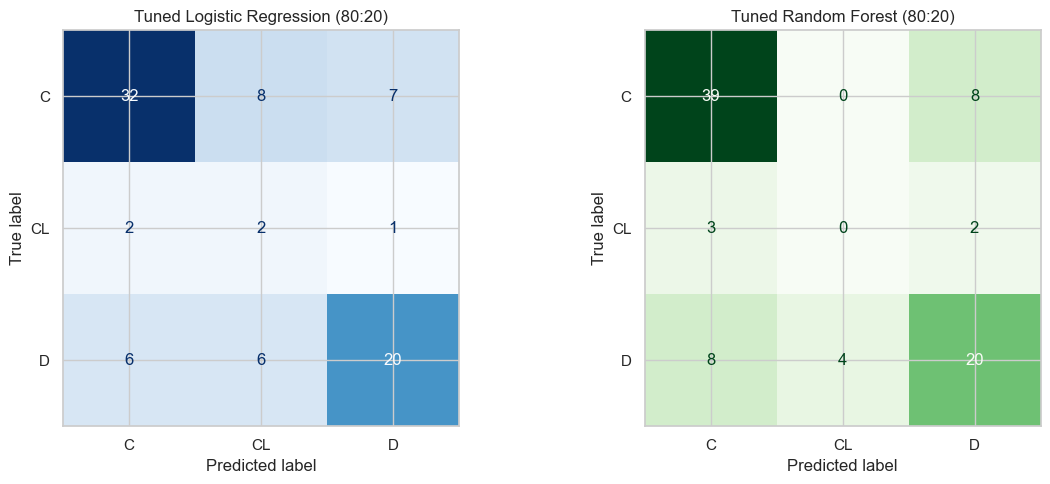

In [28]:
# Evaluate the tuned Logistic Regression model
logistic_accuracy_80 = accuracy_score(
    y_test_80,
    logistic_test_predictions_80
)

logistic_precision_80 = precision_score(
    y_test_80,
    logistic_test_predictions_80,
    average="macro",
    zero_division=0
)

logistic_recall_80 = recall_score(
    y_test_80,
    logistic_test_predictions_80,
    average="macro",
    zero_division=0
)

logistic_f1_80 = f1_score(
    y_test_80,
    logistic_test_predictions_80,
    average="macro",
    zero_division=0
)

logistic_auc_80 = roc_auc_score(
    y_test_80,
    logistic_test_probabilities_80,
    multi_class="ovr",
    average="macro"
)

# Evaluate the tuned Random Forest model
random_forest_accuracy_80 = accuracy_score(
    y_test_80,
    random_forest_test_predictions_80
)

random_forest_precision_80 = precision_score(
    y_test_80,
    random_forest_test_predictions_80,
    average="macro",
    zero_division=0
)

random_forest_recall_80 = recall_score(
    y_test_80,
    random_forest_test_predictions_80,
    average="macro",
    zero_division=0
)

random_forest_f1_80 = f1_score(
    y_test_80,
    random_forest_test_predictions_80,
    average="macro",
    zero_division=0
)

random_forest_auc_80 = roc_auc_score(
    y_test_80,
    random_forest_test_probabilities_80,
    multi_class="ovr",
    average="macro"
)

# Comparison table
comparison_80 = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy_80,
        random_forest_accuracy_80
    ],
    "Macro Precision": [
        logistic_precision_80,
        random_forest_precision_80
    ],
    "Macro Recall": [
        logistic_recall_80,
        random_forest_recall_80
    ],
    "Macro F1-score": [
        logistic_f1_80,
        random_forest_f1_80
    ],
    "Macro ROC-AUC": [
        logistic_auc_80,
        random_forest_auc_80
    ]
})

display(comparison_80.round(4))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_80,
    logistic_test_predictions_80,
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("Tuned Logistic Regression (80:20)")

ConfusionMatrixDisplay.from_predictions(
    y_test_80,
    random_forest_test_predictions_80,
    ax=axes[1],
    cmap="Greens",
    colorbar=False
)
axes[1].set_title("Tuned Random Forest (80:20)")

plt.tight_layout()
plt.show()

 ### Robustness Evaluation

With the 80:20 split, Logistic Regression achieved a higher Macro F1-score (0.5309), Macro Recall (0.5686) and ROC-AUC (0.7798). Random Forest achieved higher accuracy (0.7024), but it failed to correctly classify any CL cases. This confirms that Logistic Regression provides more balanced performance across all classes and remains the more reliable model.

### Final Recommendation

Tuned Logistic Regression is recommended as the final model because it produced the most balanced performance across all three outcome classes. Although the tuned Random Forest achieved higher overall accuracy, much of this improvement came from stronger predictions for the majority class C. It performed poorly for the minority class CL and failed to identify any CL cases in the 80:20 test split.

In comparison, Logistic Regression achieved higher Macro Recall, Macro F1-score and Macro ROC-AUC. It also correctly identified more CL cases across both train-test splits. Its results remained relatively consistent between the 70:30 and 80:20 evaluations, indicating better robustness and generalisation.

Therefore, Logistic Regression is more suitable for this task because it provides a better balance between overall predictive performance and minority-class detection. However, the limited number of CL observations remains a major limitation, so additional minority-class data would be required before considering real-world deployment.